In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import gzip
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [16]:
class Graph:
    def __init__(self):
        self.adj_list = {}
    
    def add_edge(self, u, v):
        if u not in self.adj_list:
            self.adj_list[u] = set()
        if v not in self.adj_list:
            self.adj_list[v] = set()
        self.adj_list[u].add(v)
        self.adj_list[v].add(u)
    
    def has_edge(self, u, v):
        return u in self.adj_list and v in self.adj_list[u]
    
    def get_neighbors(self, node):
        return self.adj_list.get(node, set())
    
    def get_degree(self, node):
        return len(self.adj_list.get(node, set()))
    
    def get_all_nodes(self):
        return list(self.adj_list.keys())
    
    def get_all_edges(self):
        edges = []
        seen = set()
        for u in self.adj_list:
            for v in self.adj_list[u]:
                edge = tuple(sorted([u, v]))
                if edge not in seen:
                    edges.append((u, v))
                    seen.add(edge)
        return edges
    
    def num_nodes(self):
        return len(self.adj_list)
    
    def num_edges(self):
        return len(self.get_all_edges())

In [17]:
filepath = "facebook_combined.txt.gz"
graph = Graph()
if filepath.endswith('.gz'):
    with gzip.open(filepath, 'rt') as f:
        for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u, v)
else:
    with open(filepath, 'r') as f:
        for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u, v)
    
num_nodes = graph.num_nodes()
num_edges = graph.num_edges()
print(f"Number of users (nodes): {num_nodes:,}")
print(f"Number of friendships (edges): {num_edges:,}")

Number of users (nodes): 4,039
Number of friendships (edges): 88,234


In [18]:
def create_train_test_split(graph, test_ratio=0.2):
    all_edges = graph.get_all_edges()
    np.random.shuffle(all_edges)
    split_idx = int(len(all_edges) * (1 - test_ratio))
    train_edges = all_edges[:split_idx]
    test_edges = all_edges[split_idx:]
    train_graph = Graph()
    for u, v in train_edges:
        train_graph.add_edge(u, v)
    for node in graph.get_all_nodes():
        if node not in train_graph.adj_list:
            train_graph.adj_list[node] = set()
    return train_graph, train_edges, test_edges

train_graph, train_edges, test_edges = create_train_test_split(graph, test_ratio=0.2)

In [19]:
def generate_negative_samples(graph, num_samples):
    all_nodes = graph.get_all_nodes()
    non_edges = []
    attempts = 0
    max_attempts = num_samples * 10
    while len(non_edges) < num_samples and attempts < max_attempts:
        u, v = np.random.choice(all_nodes, size=2, replace=False)
        if not graph.has_edge(u, v):
            edge = tuple(sorted([u, v]))
            if edge not in non_edges:
                non_edges.append((u, v))
        attempts += 1
    print(f"Generated {len(non_edges):,} negative samples")
    return non_edges

# Generate negative samples
non_edges = generate_negative_samples(graph, len(test_edges))  

Generated 17,647 negative samples


In [ ]:
def common_neighbors(graph, u, v):
    neighbors_u = graph.get_neighbors(u)
    neighbors_v = graph.get_neighbors(v)
    return len(neighbors_u & neighbors_v)

def jaccard_coefficient(graph, u, v):
    """
    Jaccard coefficient = |intersection| / |union|
    Measures similarity of neighbor sets
    """
    neighbors_u = graph.get_neighbors(u)
    neighbors_v = graph.get_neighbors(v)
    intersection = len(neighbors_u & neighbors_v)
    union = len(neighbors_u | neighbors_v)
    if union == 0:
        return 0
    return intersection / union

def adamic_adar_index(graph, u, v):
    """
    Adamic-Adar: sum of 1/log(degree(w)) for each common neighbor w
    Weights rare common neighbors higher than popular ones
    """
    neighbors_u = graph.get_neighbors(u)
    neighbors_v = graph.get_neighbors(v)
    common = neighbors_u & neighbors_v
    
    score = 0
    for neighbor in common:
        degree = graph.get_degree(neighbor)
        if degree > 1:
            score += 1 / np.log(degree)
    return score

def preferential_attachment(graph, u, v):
    """
    Preferential attachment = degree(u) * degree(v)
   Popular nodes tend to form more connections
    """ 
    return graph.get_degree(u) * graph.get_degree(v)

def resource_allocation_index(graph, u, v):
    """
    Resource allocation: sum of 1/degree(w) for common neighbors w
    Similar to Adamic-Adar but without logarithm
    """
    neighbors_u = graph.get_neighbors(u)
    neighbors_v = graph.get_neighbors(v)
    common = neighbors_u & neighbors_v
    score = 0
    for neighbor in common:
        degree = graph.get_degree(neighbor)
        if degree > 0:
            score += 1 / degree
    return score

In [ ]:
# Prepare dataset
def extract_features_for_edge(train_graph, u, v):
    degree_u = train_graph.get_degree(u)
    degree_v = train_graph.get_degree(v)
    features = {
        'degree_u': degree_u,
        'degree_v': degree_v,
        'degree_sum': degree_u + degree_v,
        'degree_product': degree_u * degree_v,
        'degree_max': max(degree_u, degree_v),
        'degree_min': min(degree_u, degree_v),
        'degree_diff': abs(degree_u - degree_v),
        'common_neighbors': common_neighbors(train_graph, u, v),
        'jaccard_coefficient': jaccard_coefficient(train_graph, u, v),
        'adamic_adar': adamic_adar_index(train_graph, u, v),
        'preferential_attachment': preferential_attachment(train_graph, u, v),
        'resource_allocation': resource_allocation_index(train_graph, u, v),
    }
    return features

def extract_features_for_edges(train_graph, edge_list, label):
    """"for multiple edges"""
    print(f"\nExtracting features for {len(edge_list):,} edges (label={label})...")
    features = []
    for i, (u, v) in enumerate(edge_list):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i:,}/{len(edge_list):,} edges...")
        edge_features = extract_features_for_edge(train_graph, u, v)
        edge_features['label'] = label
        features.append(edge_features)
    df = pd.DataFrame(features)
    print(f"  Extracted {len(df.columns) - 1} featues")
    return df


def prepare_dataset(train_graph, test_edges, non_edges):
    print("\nProcessing positive samples")
    positive_features = extract_features_for_edges(train_graph, test_edges, label=1)
    print("\nProcessing negative samples")
    negative_features = extract_features_for_edges(train_graph, non_edges, label=0)
    # Combine
    dataset = pd.concat([positive_features, negative_features], ignore_index=True)
    dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Total samples: {len(dataset):,}")
    print(f"Positive: {sum(dataset['label'] == 1):,}")
    print(f"Negative: {sum(dataset['label'] == 0):,}")
    print(f"Features: {len(dataset.columns) - 1}")
    return dataset

dataset = prepare_dataset(train_graph, test_edges, non_edges)


Processing positive samples

Extracting features for 17,647 edges (label=1)...
  Processed 1,000/17,647 edges...
  Processed 2,000/17,647 edges...
  Processed 3,000/17,647 edges...
  Processed 4,000/17,647 edges...
  Processed 5,000/17,647 edges...
  Processed 6,000/17,647 edges...
  Processed 7,000/17,647 edges...
  Processed 8,000/17,647 edges...
  Processed 9,000/17,647 edges...
  Processed 10,000/17,647 edges...
  Processed 11,000/17,647 edges...
  Processed 12,000/17,647 edges...
  Processed 13,000/17,647 edges...
  Processed 14,000/17,647 edges...
  Processed 15,000/17,647 edges...
  Processed 16,000/17,647 edges...
  Processed 17,000/17,647 edges...
  Extracted 12 featues

Processing negative samples

Extracting features for 17,647 edges (label=0)...
  Processed 1,000/17,647 edges...
  Processed 2,000/17,647 edges...
  Processed 3,000/17,647 edges...
  Processed 4,000/17,647 edges...
  Processed 5,000/17,647 edges...
  Processed 6,000/17,647 edges...
  Processed 7,000/17,647 ed

In [24]:
def train_and_evaluate_models(dataset):
    X = dataset.drop('label', axis=1)
    y = dataset['label']
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    print(f"Training samples: {len(X_train):,}")
    print(f"Validation samples: {len(X_val):,}")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train Random Forest only
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    results = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\nPerformance Metrics:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC-ROC:   {auc:.4f}")
    
    cm = confusion_matrix(y_val, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  Predicted:  No    Yes")
    print(f"Actual No   [{cm[0,0]:5d} {cm[0,1]:5d}]")
    print(f"Actual Yes  [{cm[1,0]:5d} {cm[1,1]:5d}]")
    
    # Feature importance
    importances = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 5 Important Features:")
    for idx, row in importances.head(5).iterrows():
        print(f"  {row['feature']:25s}: {row['importance']:.4f}")
    
    return results, y_val, X.columns

results, y_val, feature_names = train_and_evaluate_models(dataset)

Training samples: 24,705
Validation samples: 10,589

Performance Metrics:
   Accuracy:  0.9749 (97.49%)
   Precision: 0.9697
   Recall:    0.9804
   F1-Score:  0.9750
   AUC-ROC:   0.9924

Confusion Matrix:
  Predicted:  No    Yes
Actual No   [ 5133   162]
Actual Yes  [  104  5190]

Top 5 Important Features:
  adamic_adar              : 0.2899
  resource_allocation      : 0.2242
  common_neighbors         : 0.2032
  jaccard_coefficient      : 0.1459
  degree_min               : 0.0503


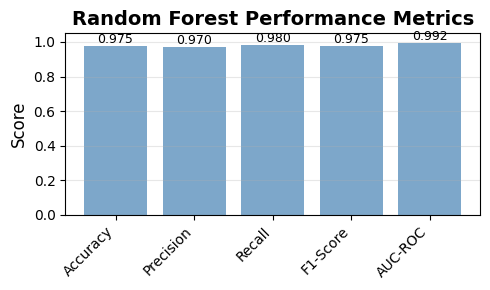

In [27]:
plt.figure(figsize=(5, 3))
metrics = {
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'AUC-ROC': results['auc']
    }
    
bars = plt.bar(metrics.keys(), metrics.values(), color='steelblue', alpha=0.7)
plt.title('Random Forest Performance Metrics', fontweight='bold', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
plt.tight_layout()
# plt.savefig('performance_metrics.png', dpi=300, bbox_inches='tight')
# print("\n✓ Saved: performance_metrics.png")
plt.show()
plt.close()

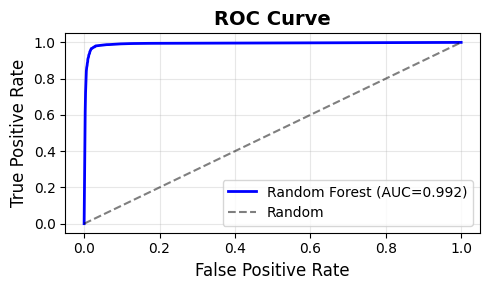

In [28]:
   # Plot 2: ROC Curve
plt.figure(figsize=(5, 3))
fpr, tpr, _ = roc_curve(y_val, results['y_pred_proba'])
plt.plot(fpr, tpr, label=f"Random Forest (AUC={results['auc']:.3f})", 
           linewidth=2, color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1.5, alpha=0.5)
plt.title('ROC Curve', fontweight='bold', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

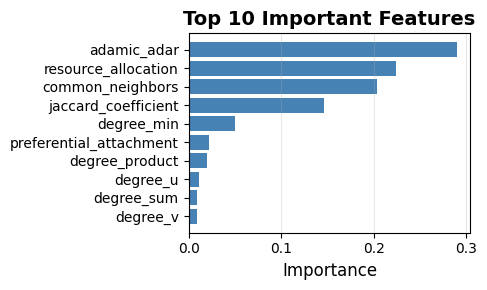

In [31]:
plt.figure(figsize=(5, 3))
model = results['model']
importances = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)
    
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.title('Top 10 Important Features', fontweight='bold', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

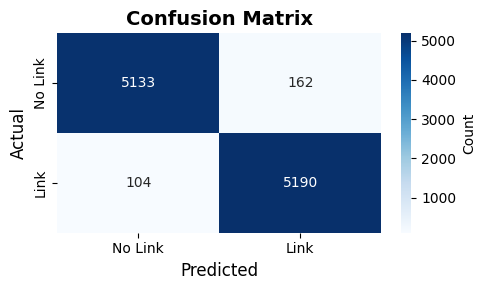

In [32]:
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_val, results['y_pred']) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Link', 'Link'],
               yticklabels=['No Link', 'Link'],
               cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()